
✅ Data Loaded Successfully!
   User_Type  CPU_Usage  RAM_Usage  Storage  App_Hours Recommended_Software
0      Gamer         87         78      420       11.4                Steam
1    Student         21         62      292        2.4               Notion
2  Developer         61         61      574        5.5              VS Code
3  Developer         51         60      360        5.8              VS Code
4   Designer         77         61      691        5.4                Figma

✅ Data Preprocessing Completed!

✅ Model Trained and Predictions Made!

📊 PERFORMANCE EVALUATIONS
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        22
           2       0.97      1.00      0.98        28
           3       1.00      0.96      0.98        26

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99   

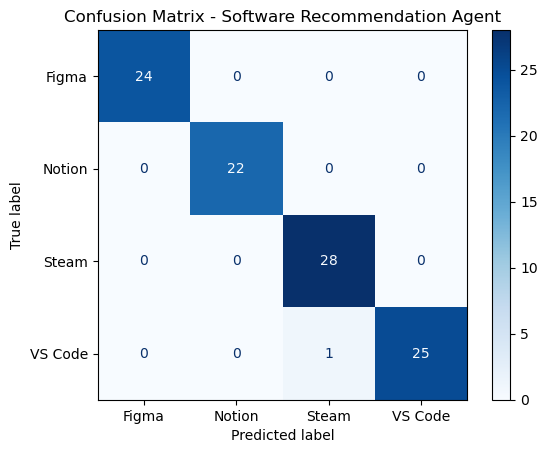


🤖 SOFTWARE RECOMMENDATION AGENT (Semi-Autonomous Mode)



Enter User Type (Developer / Designer / Student / Gamer):  Student
Enter CPU Usage (%):  25
Enter RAM Usage (%):  24
Enter Storage (GB):  22
Enter App Usage (hrs/day):  5



💡 Recommended Software: Notion



Press Enter to continue or 'q' to quit:  

Enter User Type (Developer / Designer / Student / Gamer):  Gamer
Enter CPU Usage (%):  75
Enter RAM Usage (%):  80
Enter Storage (GB):  50
Enter App Usage (hrs/day):  8



💡 Recommended Software: VS Code


In [ ]:
# =====================================================
# SOFTWARE RECOMMENDATION AGENT USING KNN CLASSIFIER
# With 400-Sample Dataset
# =====================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---------------------------- Agent Class --------------------------------------
class LearningAgentKNN:
    def __init__(self):
        self.df = None
        self.scaler = None
        self.kNN_learner = None

    # ------------------ Load Data ------------------
    def load_data(self, file_path):
        df = pd.read_csv(file_path)
        print("\n✅ Data Loaded Successfully!")
        print(df.head())
        self.df = df

    # ------------------ Data Preprocessing ------------------
    def data_preprocessing(self):
        df = self.df.copy()
        self.label_encoder_user = LabelEncoder()
        self.label_encoder_software = LabelEncoder()

        df['User_Type_Encoded'] = self.label_encoder_user.fit_transform(df['User_Type'])
        df['Software_Encoded'] = self.label_encoder_software.fit_transform(df['Recommended_Software'])

        features = df[['CPU_Usage', 'RAM_Usage', 'Storage', 'App_Hours', 'User_Type_Encoded']]
        label = df['Software_Encoded']

        X_train, X_test, y_train, y_test = train_test_split(features, label, test_size=0.25, random_state=42)

        self.scaler = StandardScaler()
        self.X_train = self.scaler.fit_transform(X_train)
        self.X_test = self.scaler.transform(X_test)
        self.y_train = y_train
        self.y_test = y_test

        print("\n✅ Data Preprocessing Completed!")

    # ------------------ Train and Predict ------------------
    def train_agent_predict_test(self):
        self.kNN_learner = KNeighborsClassifier(n_neighbors=3)
        self.kNN_learner.fit(self.X_train, self.y_train)
        self.pred = self.kNN_learner.predict(self.X_test)
        print("\n✅ Model Trained and Predictions Made!")

    # ------------------ Evaluate ------------------
    def evaluate_KNN_agent(self):
        print('\n📊 PERFORMANCE EVALUATIONS')
        print(classification_report(self.y_test, self.pred))
        print("Accuracy Score = ", round(accuracy_score(self.y_test, self.pred) * 100, 2), "%")

        cm = confusion_matrix(self.y_test, self.pred, labels=self.kNN_learner.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                      display_labels=self.label_encoder_software.inverse_transform(self.kNN_learner.classes_))
        disp.plot(cmap='Blues')
        plt.title("Confusion Matrix - Software Recommendation Agent")
        plt.show()

    # ------------------ Predict New Instance ------------------
    def predict_new_percept(self, user_type, cpu, ram, storage, app_hours):
        try:
            user_encoded = self.label_encoder_user.transform([user_type])[0]
            new_input = pd.DataFrame([[cpu, ram, storage, app_hours, user_encoded]],
                                     columns=['CPU_Usage', 'RAM_Usage', 'Storage', 'App_Hours', 'User_Type_Encoded'])

            scaled_input = self.scaler.transform(new_input)
            prediction_encoded = self.kNN_learner.predict(scaled_input)[0]
            prediction = self.label_encoder_software.inverse_transform([prediction_encoded])[0]

            print(f"\n💡 Recommended Software: {prediction}")
        except Exception as e:
            print("⚠️ Error in prediction:", e)


# ---------------------------- Class Driver --------------------------------------
if __name__ == "__main__":
    agent = LearningAgentKNN()

    # Load dataset (400 samples)
    file_path = "Software_Recommendation_Data.csv"
    agent.load_data(file_path)
    agent.data_preprocessing()
    agent.train_agent_predict_test()
    agent.evaluate_KNN_agent()

    # Semi-Autonomous Prediction Loop
    print("\n🤖 SOFTWARE RECOMMENDATION AGENT (Semi-Autonomous Mode)")
    while True:
        user_type = input("\nEnter User Type (Developer / Designer / Student / Gamer): ")
        cpu = int(input("Enter CPU Usage (%): "))
        ram = int(input("Enter RAM Usage (%): "))
        storage = int(input("Enter Storage (GB): "))
        app_hours = float(input("Enter App Usage (hrs/day): "))

        agent.predict_new_percept(user_type, cpu, ram, storage, app_hours)

        n = input("\nPress Enter to continue or 'q' to quit: ")
        if n.strip().lower() == 'q':
           print("\n🧠 Exiting the Software Recommendation Agent...")
           break
